# Lesson 05b: Radial Basis Functions and Smooth Cutoffs

**What you will learn**

- Why a raw interatomic distance, $d_{ij}$, is a poor choice as a network input,
  and why we often expand it in a **radial basis**.
- The **Gaussian basis** of SchNet and the **Bessel basis** of DimeNet.
- Why interaction features must **smoothly** go to zero at $r_\mathrm{cut}$: the
  energy must be at least $C^{(1)}$ for forces $\vec F = -\nabla E$ to exist and
  be continuous. $C^{(1)}$ means that the function is continuous and has a
  continuous first derivative (Continuously differentiable to the first order).
- The **cosine cutoff** (Behler-Parrinello) and DimeNet's **polynomial
  envelope** $u(d)$.
- A numerical demonstration of the force artifacts caused by a hard cutoff.

**Prerequisites:** 

- Lesson 05a: Radius graphs, the edge vector convention $\vec r_{ij} = \vec r_j - \vec r_i$,
  knowlede of the fact that the edges switch on/off at $r_\mathrm{cut}$.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import math

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## Why raw distance is a poor input for a neural network

Lesson 05a gave every edge a displacement vector, $\vec r_{ij}$. Its **length**,
$d_{ij} = \lVert\vec r_{ij}\rVert$, is the rotation-invariant part, and it
enters the network as the output of a learned radial function, $R(d_{ij})$
(Lesson 06a). A naive approach is to feed the scalar, $d_{ij}$, straight into an
MLP. This method is problematic for two reasons:

1. **Near-linear initialization.** In an architecture such as SchNet, the
   unprocessed input could lead to highly correlated filters and a
   close-to-linear model, right after the initialization. This leads to a
   learning plateau at the beginning of the training, which is difficult to
   overcome. Furthermore, a one-dimensional input gives every filter almost the
   same shape at the start of training.

2. **No locality / frequency control.** A single scalar gives the network no
   handle on *where* along the axis the structure lives. Expanding $d$ into $N$
   localized (or band-limited) functions is a *soft one-hot encoding* of the
   distance, which may be considered as the continuous analogue of pixels which
   limits the maximum frequency the model can express. DimeNet exploits this
   property, deliberately: the Bessel basis bounds the highest frequency by
   $\omega_{d} \leq N_\mathrm{RBF} \pi/c$, which *"is an effective way
   of regularizing the model and ensures that predictions are stable to small
   perturbations"*.

As such, instead of $d_{ij} \in \mathbb{R}$, the network receives a feature
vector, $\mathbf{e}(d_{ij}) \in \mathbb{R}^{N_\mathrm{basis}}$.

## The Gaussian basis in SchNet

The SchNet architecture expands the distances on a grid of Gaussian functions, 

$$
e_k(\vec r_i - \vec r_j) = \exp\!\left(-\gamma\,\lVert d_{ij} - \mu_k \rVert^2\right),
$$

which are centered at $0\,\text{Å} \le \mu_k \le 30\,\text{Å}$ every
$0.1\,\text{Å}$ and scaled by $\gamma = 10\,\text{Å}$. The width parameter,
$\gamma$, has the units of $\text{Å}^{-2}$. That is **300 basis functions**: a
dense, redundant grid of Gaussians. Each $e_k$ responds only near its center,
$\mu_k$, which translates to a soft binning of the distance axis.

Let's implement the Gaussian grid in PyTorch.

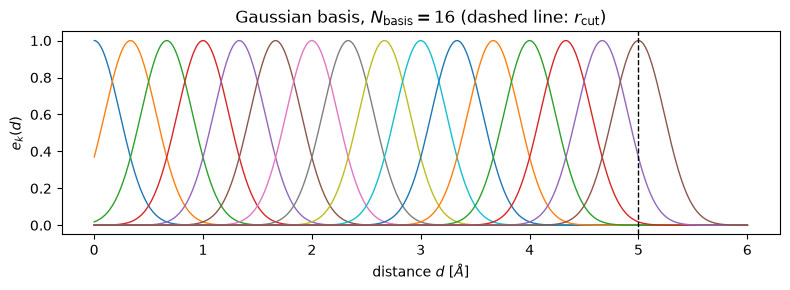

In [2]:
# Define the Gaussian basis as a PyTorch module
class GaussianBasis(torch.nn.Module):
    """SchNet-style Gaussian radial basis (Schütt et al. 2017).
    e_k(d) = exp(-gamma (d - mu_k)^2),  
    mu_k on a uniform grid in [0, r_cut].
    """

    def __init__(self, r_cut: float, n_basis: int = 16, gamma: float | None = None):
        super().__init__()
        
        # Create a uniform grid of centers mu_k in [0, r_cut]
        mu = torch.linspace(0.0, r_cut, n_basis)
        
        # Register mu as a buffer so it is not a learnable parameter but still
        # moves with the module
        self.register_buffer("mu", mu)
        
        # Default width grid spacing 
        # In SchNet with 0.1 A spacing, we set gamma = 10 A^-2
        self.gamma = gamma if gamma is not None else 1.0 / (mu[1] - mu[0]) ** 2

    # d: (E,) -> (E, n_basis)
    def forward(self, d):
        return torch.exp(-self.gamma * (d.unsqueeze(-1) - self.mu) ** 2)

# Set the cutoff radius in Angstroms
r_cut = 5.0

# Create a distance array from 1e-3 to r_cut + 1.0 with 500 points
d = torch.linspace(1e-3, r_cut + 1.0, 500)

# Create a Gaussian basis with the specified cutoff and number of basis
# functions on the grid of distances d.
gauss = GaussianBasis(r_cut, n_basis=16)

# Plot the Gaussian basis functions and the cutoff radius
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(d, gauss(d).numpy(), lw=1)
ax.axvline(r_cut, color="k", ls="--", lw=1)
ax.set_xlabel(r"distance $d$ [$\AA$]")
ax.set_ylabel(r"$e_k(d)$")
ax.set_title(r"Gaussian basis, $N_\mathrm{basis}=16$ (dashed line: $r_\mathrm{cut}$)")
fig.tight_layout()
plt.show()

Note the flaw visible at the dashed line: **the Gaussians do not vanish at
$r_\mathrm{cut}$**. The last function value is still large there.

## The Bessel basis in DimeNet

DimeNet replaces the ad-hoc Gaussian grid with a *theoretically justified*
basis: the radial solutions of the Helmholtz equation $(\nabla^2 + k^2)\Psi = 0$
on a ball of radius $c = r_\mathrm{cut}$ with $\Psi(c)=0$: the same functions
that describe a free quantum particle in a spherical box. For $l = 0$, the
spherical Bessel function is $j_0(d) = \sin(d)/d$ with roots at $z_{0,n} =
n\pi$. Normalizing on $[0, c]$ gives the radial basis:

$$
\tilde e_{\mathrm{RBF},n}(d) \;=\; \sqrt{\frac{2}{c}}\, \frac{\sin\!\left(\frac{n\pi}{c} d\right)}{d},
\qquad n \in [1 \,..\, N_\mathrm{RBF}] .
$$

The Bessel basis has several desirable properties. They are:

- **Orthogonal** on $[0, c]$, so the features are decorrelated;
- **Band-limited**: frequency of component $n$ is exactly $n\pi/c$;
- **Compact**: The creators of DimeNet found $N_\mathrm{RBF} = 16$ sufficient
  for their experiments;
- All components vanish at $d = c$ (though, not smoothly enough).

DimeNet additionally fine-tunes the Bessel wave numbers $k_n = \frac{n\pi}{c}$
... via backpropagation, after initializing them. We incorporate this capability
via a `trainable` flag.

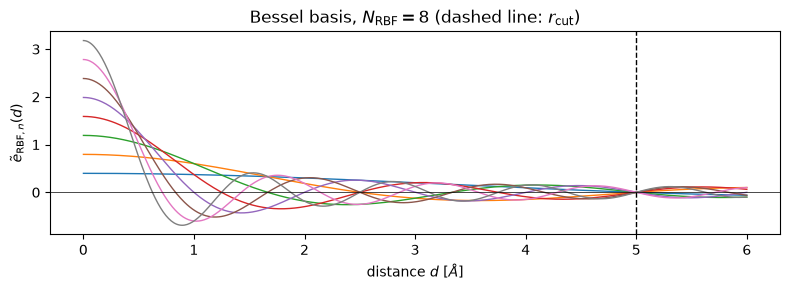

In [3]:
# Create a Bessel basis as a PyTorch module
class BesselBasis(torch.nn.Module):
    """DimeNet radial Bessel basis, (Gasteiger et al. 2022).
    e_n(d) = sqrt(2/c) * sin(k_n d) / d,
    k_n = n pi / c  (optionally trainable).
    """

    def __init__(self, r_cut: float, n_basis: int = 8, trainable: bool = False):
        super().__init__()
        self.r_cut = r_cut
        self.prefactor = math.sqrt(2.0 / r_cut)
        k_n = torch.arange(1, n_basis + 1) * math.pi / r_cut
        if trainable:
            self.k_n = torch.nn.Parameter(k_n)
        else:
            self.register_buffer("k_n", k_n)

    # d: (E,) -> (E, n_basis)
    def forward(self, d):
        d = d.unsqueeze(-1)
        return self.prefactor * torch.sin(self.k_n * d) / d


# Initialize a Bessel basis with the specified cutoff and number of basis
# functions
bessel = BesselBasis(r_cut, n_basis=8)

# Plot the Bessel basis functions and the cutoff radius
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(d, bessel(d).numpy(), lw=1)
ax.axvline(r_cut, color="k", ls="--", lw=1)
ax.axhline(0.0, color="k", lw=0.5)
ax.set_xlabel(r"distance $d$ [$\AA$]")
ax.set_ylabel(r"$\tilde e_{\mathrm{RBF},n}(d)$")
ax.set_title(r"Bessel basis, $N_\mathrm{RBF}=8$ (dashed line: $r_\mathrm{cut}$)")
fig.tight_layout()
plt.show()

## Smooth cutoffs: the energy must be $C^1$

Recall from Lesson 05a that edges *appear and disappear* as atoms cross
$r_\mathrm{cut}$. A model energy is a sum over edges, 

$$ 
E(\{\vec r\}) = \sum_{(i,j) \in \mathcal{E}} \varepsilon\!\left(d_{ij}, \ldots\right)
$$.

Thus, when an atom crosses the cutoff, the edge term $\varepsilon$ is abruptly
added or removed. Consequently, the **force** on atom $k$, $\vec F_k = -\partial
E / \partial \vec r_k$, can also change abruptly. In particular,

- if $\varepsilon(r_\mathrm{cut}) \neq 0$, $E$ is **discontinuous** and the
  force contains a Dirac-delta spike (undefined at the crossing), which is
  disastrous in molecular dynamics because the energy is not conserved;
- if $\varepsilon(r_\mathrm{cut}) = 0$ but its first derivative,
  $\varepsilon'(r_\mathrm{cut}) \neq 0$, $E$ is continuous but only $C^{(0)}$:
  the force **jumps** discontinuously.

As such, we need $\varepsilon$ (and hence every radial feature) to reach zero at
$r_\mathrm{cut}$ **with zero slope**: The energy is then $C^{(1)}$ and forces
are continuous. Smoother energy function is more desirable for integrators and
autograd engines (e.g., a $C^{(2)}$ energy will be beneficial for calculating
second derivatives).

A remedy to this problem is a multiplicative **cutoff / envelope function**.
There are at least two popular choices in the literature:

1. **Cosine cutoff**, introduced by Behler & Parrinello in 2007 for atom-centered
symmetry functions:

$$
f_c(d) =
\begin{cases}
\tfrac{1}{2}\left[\cos\!\left(\dfrac{\pi d}{r_c}\right) + 1\right], & d \le r_c\\[4pt]
0, & d > r_c
\end{cases}
$$

which has $f_c(r_c) = 0$ and $f_c'(r_c) = 0$: As such, the function is $C^1$ at
the cutoff (though its second derivative is discontinuous at $r_c$).

2. **Polynomial envelope**, used in DimeNet. The Bessel basis vanishes at $c$
   but is not twice continuously differentiable due to the step function cutoff
   at $c$. Thus, DimeNet multiplies it by an envelope, $u(d)$, that has a root
   of multiplicity 3 at $d = c$. Here, $d$ is the distance in the same units as
   that of the cutoff and $d \to d/c \in [0,1]$:
    
$$
u(d) = 1 - \frac{(p+1)(p+2)}{2}\, d^{p} + p(p+2)\, d^{p+1} - \frac{p(p+1)}{2}\, d^{p+2},
$$

Here, $p \in \mathbb{N}_0$, and the coefficients are chosen so that $u(1) =
u'(1) = u''(1) = 0$ while $u(0) = 1$ with $p-1$ vanishing derivatives at the
origin. DimeNet uses $p = 6$ and reports the model is insensitive to different
choices of envelope functions. The enveloped basis is then: 

$$ e_{\mathrm{RBF}}(d) = u(d)\,\tilde e_{\mathrm{RBF}}(d). $$

Let us implement both the cosine cutoff and the polynomial envelope in PyTorch.

In [4]:
# Define the cosine cutoff function as a PyTorch module
class CosineCutoff(torch.nn.Module):
    """f_c(d) = 0.5 (cos(pi d / r_c) + 1) for d <= r_c, else 0 (Behler & Parrinello 2007)."""

    def __init__(self, r_cut: float):
        super().__init__()
        self.r_cut = r_cut

    def forward(self, d):
        return torch.where(d < self.r_cut,
                           0.5 * (torch.cos(math.pi * d / self.r_cut) + 1.0),
                           torch.zeros_like(d))

# Define the polynomial envelope function as a PyTorch module
class PolynomialCutoff(torch.nn.Module):
    """DimeNet envelope u(d), with d -> d/r_cut."""

    def __init__(self, r_cut: float, p: int = 6):
        super().__init__()
        self.r_cut, self.p = r_cut, p

    def forward(self, d):
        # Compute the polynomial envelope
        x, p = d / self.r_cut, self.p
        u = (1.0 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
             - p * (p + 1) / 2 * x**(p + 2))
        return torch.where(d < self.r_cut, u, torch.zeros_like(d))

Now, let's visualize the values and first derivatives of both cutoff functions.

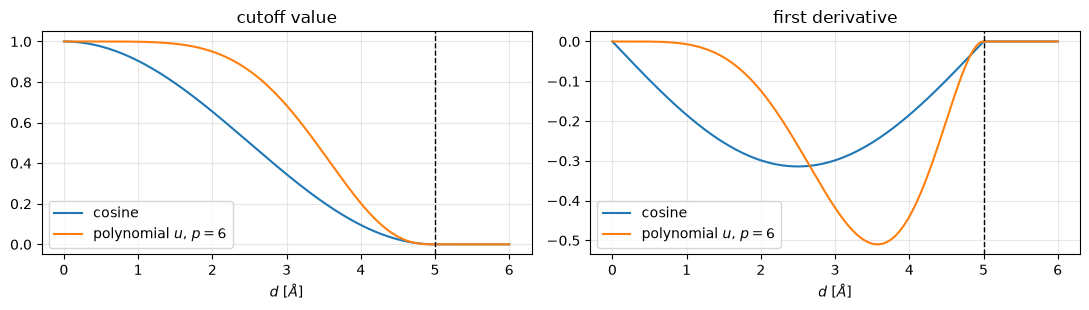

at r_cut: cosine f_c = 0.00e+00,  poly u = 0.00e+00  (both -> 0)


In [5]:
# Values and first derivatives (by autograd) of both cutoff functions
cos_cut, poly_cut = CosineCutoff(r_cut), PolynomialCutoff(r_cut, p=6)

# Create a uniform grid of distances from 1e-3 to r_cut + 1.0 with 800 points,
# and enable gradient computation
d_g = torch.linspace(1e-3, r_cut + 1.0, 800, requires_grad=True)

# Plot the values and first derivatives of both cutoff functions
fig, (axV, axD) = plt.subplots(1, 2, figsize=(11, 3.2))
for f, name in [(cos_cut, "cosine"), (poly_cut, "polynomial $u$, $p=6$")]:
    # Compute the function values at the grid points
    y = f(d_g)
    
    # Compute the first derivative of the function values with respect to the
    # grid points
    (dy,) = torch.autograd.grad(y.sum(), d_g, create_graph=False, retain_graph=False)
    
    # Plot the function values and first derivatives on the respective axes
    axV.plot(d_g.detach(), y.detach(), label=name)
    axD.plot(d_g.detach(), dy, label=name)

# Add vertical line at r_cut, legends, grid, labels, and titles to both subplots
for ax, title in [(axV, "cutoff value"), (axD, "first derivative")]:
    ax.axvline(r_cut, color="k", ls="--", lw=1)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$d$ [$\AA$]")
    ax.set_title(title)
fig.tight_layout()
plt.show()

# Check the values of both cutoff functions at r_cut - 1e-9 to ensure they
# approach zero
x1 = torch.tensor(r_cut - 1e-9)
print(f"at r_cut: cosine f_c = {cos_cut(x1):.2e},  poly u = {poly_cut(x1):.2e}  (both -> 0)")

Time to implement and visualize the DimeNet's final radial features

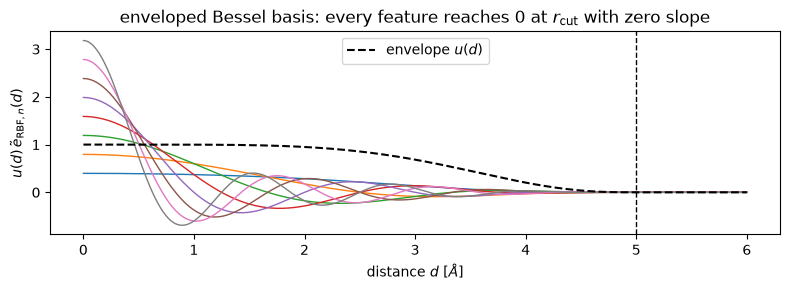

In [6]:
# DimeNet's final radial features:
# e_RBF(d) = u(d) * e~_RBF(d)
env = poly_cut(d).unsqueeze(-1)

# Plot the enveloped Bessel basis functions and the cutoff radius
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(d, (env * bessel(d)).detach().numpy(), lw=1)
ax.plot(d, poly_cut(d).detach().numpy(), "k--", lw=1.5, label=r"envelope $u(d)$")
ax.axvline(r_cut, color="k", ls="--", lw=1)
ax.set_xlabel(r"distance $d$ [$\AA$]")
ax.set_ylabel(r"$u(d)\,\tilde e_{\mathrm{RBF},n}(d)$")
ax.set_title("enveloped Bessel basis: every feature reaches 0 at $r_\\mathrm{cut}$ with zero slope")
ax.legend()
fig.tight_layout()
plt.show()

## Numerical demonstration: hard cutoffs break forces

Let us begin working with a simple examplpe system: a diatomic molecule with
atomic centers at a distance $r$ apart. The energy of this model system can be
expressed as a fixed linear read-out $E(r) = \mathbf{w}^\top \mathbf{e}(r)$ of
the radial features (this is exactly what the trained networks of Lessons 06-10
do, with $\mathbf{w}$ produced by an MLP). 

We compare three feature choices as the atom crosses $r_\mathrm{cut}$:

1. **Gaussian basis with a hard cutoff**: The features are truncated by the edge
   list $\mathbf e(r)\,\theta(r < r_\mathrm{cut})$. Since $\mathbf
   e(r_\mathrm{cut}) \ne 0$, the *energy itself* jumps.
2. **Bessel basis, no envelope**: $\tilde{\mathbf
   e}_\mathrm{RBF}(r_\mathrm{cut}) = 0$, so $E$ is continuous, but the slope is
   not. As such, the *force* jumps.
3. **Bessel $\times$ polynomial envelope**: Energy *and* its first derivative
   vanish at $r_\mathrm{cut}$: The energy is $C^2$ and the force is continuous.

Let us now evaluate $F(r) = -\mathrm{d}E/\mathrm{d}r$ by autograd on a dense
grid through the cutoff.

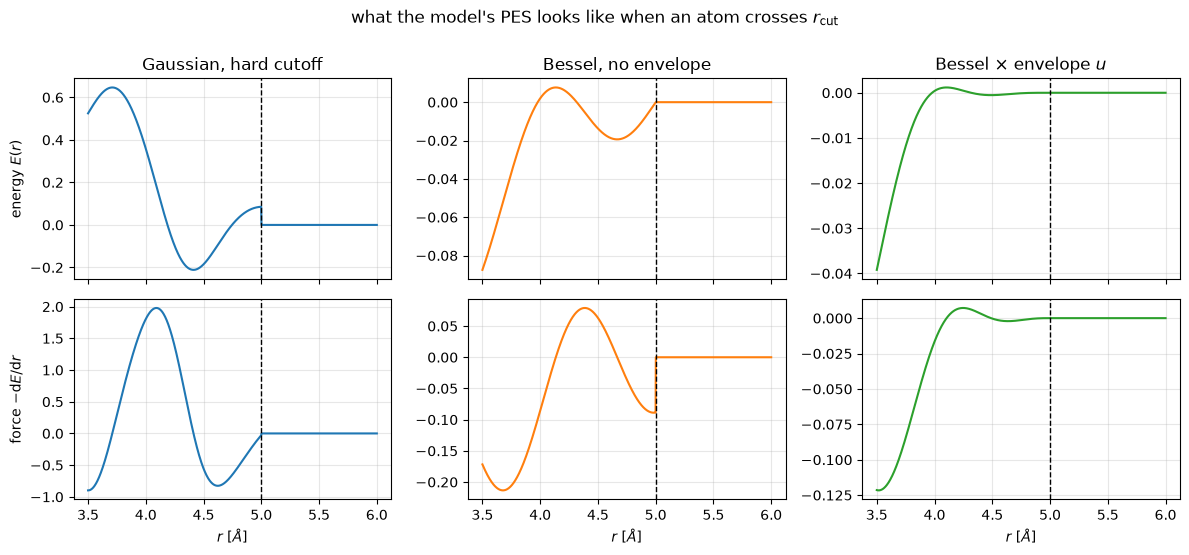

In [7]:
# Set a fixed random seed for reproducibility
torch.manual_seed(0)

# Define random weights for the Gaussian and Bessel basis functions
# Fixed random read-out weights ("a trained model")
w_g = torch.randn(16) / 4.0
w_b = torch.randn(8) / 4.0

# Create a uniform grid of distances from 3.5 to 6.0 with 1200 points, and
# enable gradient computation
r = torch.linspace(3.5, 6.0, 1200, requires_grad=True)

# Define a boolean mask to indicate which distances are inside the cutoff radius
# The edge exists only inside the cutoff (Lesson 05a)
inside = (r < r_cut)

# Compute the energy contributions from the Gaussian basis with a hard cutoff
E_hard_gauss = torch.where(inside, gauss(r) @ w_g, torch.zeros_like(r))

# Compute the energy contributions from the Bessel basis without an envelope
E_bare_bessel = torch.where(inside, bessel(r) @ w_b, torch.zeros_like(r))

# Compute the energy contributions from the Bessel basis with a polynomial envelope
E_smooth = torch.where(inside, (poly_cut(r).unsqueeze(-1) * bessel(r)) @ w_b,
                       torch.zeros_like(r))

# Create a list of tuples containing the energy contributions and their corresponding names
cases = [(E_hard_gauss, "Gaussian, hard cutoff"),
         (E_bare_bessel, "Bessel, no envelope"),
         (E_smooth, r"Bessel $\times$ envelope $u$")]

# Create subplots to visualize the energy contributions and their corresponding forces
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True)
for col, (E, name) in enumerate(cases):
    (dE,) = torch.autograd.grad(E.sum(), r, retain_graph=True)
    axes[0, col].plot(r.detach(), E.detach(), color=f"C{col}")
    axes[1, col].plot(r.detach(), -dE, color=f"C{col}")
    axes[0, col].set_title(name)
    for row in (0, 1):
        axes[row, col].axvline(r_cut, color="k", ls="--", lw=1)
        axes[row, col].grid(alpha=0.3)
axes[0, 0].set_ylabel(r"energy $E(r)$")
axes[1, 0].set_ylabel(r"force $-\mathrm{d}E/\mathrm{d}r$")
for col in range(3):
    axes[1, col].set_xlabel(r"$r$ [$\AA$]")
fig.suptitle(r"what the model's PES looks like when an atom crosses $r_\mathrm{cut}$", y=1.0)
fig.tight_layout()
plt.show()

Let's quantify the discontinuities by comparing both sides of the cutoff

In [8]:
# Set a small epsilon value
eps = 1e-7

# Compute a grid of two points just below and above the cutoff radius, and
# enable gradient computation
r2 = torch.tensor([r_cut - eps, r_cut + eps], requires_grad=True)

# Quantify the discontinuities by comparing both sides of the cutoff
for feats, w, name in [(lambda x: gauss(x), w_g, "Gaussian, hard cutoff "),
                       (lambda x: bessel(x), w_b, "Bessel,  no envelope  "),
                       (lambda x: poly_cut(x).unsqueeze(-1) * bessel(x), w_b,
                        "Bessel x envelope     ")]:
    # Calculate the energy contributions for the two points just below and above the cutoff radius
    E = torch.where(r2 < r_cut, feats(r2) @ w, torch.zeros_like(r2))
    
    # Calculate the gradient of the energy contributions with respect to the two points
    (dE,) = torch.autograd.grad(E.sum(), r2)
    
    # Print the absolute differences in energy and force across the cutoff radius
    print(f"{name}:  jump in E = {abs(E[0] - E[1]):.3e},  jump in force = {abs(dE[0] - dE[1]):.3e}")

Gaussian, hard cutoff :  jump in E = 8.549e-02,  jump in force = 2.739e-02
Bessel,  no envelope  :  jump in E = 8.860e-09,  jump in force = 8.860e-02
Bessel x envelope     :  jump in E = 3.148e-23,  jump in force = 3.148e-16


The resulting numbers are exactly as expected: the hard-cutoff Gaussian model
has a *finite jump in the energy* (a delta-function force: the printed force
jump is only the difference of the one-sided derivatives. The spike itself is
infinite). The bare Bessel model has a continuous energy but a *finite jump in
the force*. The enveloped model is clean. In molecular dynamics the first two
feature models will result in an energy drift and an unphysical heating every
time a neighbor crosses the cutoff sphere.

## Typical hyperparameters

The following table summarizes the typical hyperparameters for radial basis
functions and cutoffs in recent literature. The choices are not unique, and the
optimal values may depend on the specific dataset and task. However, these
values are a good starting point for new experiments.

| choice | symbol | typical values | notes |
|---|---|---|---|
| Cutoff radius | $r_\mathrm{cut}$ ($c$) | 4–6 Å | DimeNet: $c = 5\,\text{Å}$; NequIP/MACE: 4–6 Å (Part IV). Larger values yield denser graphs and the cost will be larger $\propto r_\mathrm{cut}^3$ (Lesson 05a). |
| # radial basis fns | $N_\mathrm{basis}$ | 8–20 | DimeNet: 16 Bessel; NequIP: 8 trainable Bessel; SchNet's 300 Gaussians are far more than what is often needed. |
| Basis type | — | Bessel ≻ Gaussian | Bessel functions are orthogonal, band-limited, fewer of them are often needed (as in DimeNet). Gaussian functions also remain popular and adequate for most applications. |
| Envelope | $u$, $f_c$ | polynomial $p{=}6$ / cosine | Any $C^1$-or-better function with $u(r_\mathrm{cut}) = u'(r_\mathrm{cut}) = 0$. DimeNet found the exact choice of the functional form to be uncritical. |
| Trainable frequencies | $k_n$ | optional | Led to a small boost in DimeNet. Also, used by NequIP. |

## Summary

- Distances often enter the network as a **radial feature vector** $\mathbf e(d)
  \in \mathbb{R}^{N_\mathrm{basis}}$, not as a bare scalar. Radial functions
  decorrelate filters at initialization and fixe the resolvable frequency
  content.
- **Gaussian basis** functions are used in SchNet where, $e_k(d) = \exp(-\gamma
  (d - \mu_k)^2)$, are computed on a grid of points.
- **Bessel basis** functions, used in DimeNet: $\tilde e_{\mathrm{RBF},n}(d) =
  \sqrt{2/c}\,\sin(n\pi d/c)/d$, create an orthogonal set of functions which are
  principled and compact.
- The input features must vanish at $r_\mathrm{cut}$ **with zero slope**, or
  forces are discontinuous. We have demonstrated the **cosine cutoff** and
  DimeNet's **polynomial envelope**, $u(d)$.

**Next:** In [Lesson 06a](06a_equivariant_convolution.ipynb), we implement the
equivariant point convolution, which uses the radial basis and cutoff functions
implemented in this lesson.

## Exercises

**1.** Verify numerically that $u$ has *a root of multiplicity 3* at the cutoff.
Also, for $p = 6$, evaluate $u$, $u'$, $u''$ at $d = r_\mathrm{cut}$ (use
autograd twice) and confirm all three vanish, while $u(0) = 1$.

<details><summary>Solution</summary>

```python
# Create a tensor for the distance just below the cutoff radius, with gradient tracking enabled
x = torch.tensor([r_cut - 1e-12], requires_grad=True)

# Calculate the polynomial envelope and its first and second derivatives at the cutoff
u = poly_cut(x)
(du,) = torch.autograd.grad(u, x, create_graph=True)
(d2u,) = torch.autograd.grad(du, x)

# u(r_cut), u'(r_cut), u''(r_cut) = ~1e-12, ~1e-9, ~1e-6 -> 0 
# (float64 round-off amplified by differentiation)
print(u.item(), du.item(), d2u.item())

# u(0) = 1.0
print(poly_cut(torch.tensor(0.0)).item())
```

Analytically, at $x = d/c = 1$, we get $u = 1 - 28 + 48 - 21 = 0$, and the
derivative coefficients $-\frac{p(p+1)(p+2)}{2} + p(p+1)(p+2) -
\frac{p(p+1)(p+2)}{2} = 0$ cancel.
</details>

**2.** Check the orthogonality of the radial bessel basis functions: compute the
overlap matrix $S_{mn} = \int_0^c \tilde e_m(d)\, \tilde e_n(d)\,
d^2\,\mathrm{d}d$ by numerical quadrature (e.g. the trapezoidal rule on 10\,000
points) and show $S \approx \mathbb{1}$. What happens to $S$ after multiplying
it by the envelope $u$?

<details><summary>Solution</summary>

```python
# Create a uniform grid of distances from 1e-6 to the cutoff radius, with 10,000 points
dd = torch.linspace(1e-6, r_cut, 10_000)

# Compute the overlap matrix S using the trapezoidal rule
# e_n(d) * d
B = bessel(dd) * dd.unsqueeze(-1)
# Compute the overlap matrix using the trapezoidal rule
S = torch.trapezoid(B.T[:, None, :] * B.T[None, :, :], dd, dim=-1)

# ~1 on the diagonal, ~1e-16 off
print(S.diag(), S.fill_diagonal_(0).abs().max())
```
With the envelope, the basis functions lose their orthonormality: The diagonal
values drops below 1 and small off-diagonal overlaps appear. The authors of
DimeNet found that this does not hurt the model performance, and the envelope is
necessary to ensure continuous forces.
</details>

**3.** Instead of an envelope, one could *subtract* each Gaussian's value at the
cutoff, $\hat e_k(d) = e_k(d) - e_k(r_\mathrm{cut})$. Does this make the energy
$C^1$? Test this hypothesis with the Section 5 experiment.

<details><summary>Solution</summary>

No. $\hat e_k(r_\mathrm{cut}) = 0$ fixes the *energy jump* (which is $C^0$) but
$\hat e_k'(r_\mathrm{cut}) = e_k'(r_\mathrm{cut}) \neq 0$. So, the *force still
jumps*, which is the same failure mode as that of the bare Bessel basis.
Rerunning the experiment with `E = torch.where(inside, (gauss(r) -
gauss(torch.tensor(r_cut))) @ w_g, 0)` shows zero energy jump but a finite force
jump. Only a multiplicative envelope with vanishing value *and* slope gives
continuous forces. </details>

## References

- [Schütt et al., *SchNet: A continuous-filter convolutional neural network for modeling quantum interactions* arXiv.1706.08566 (2017)](https://arxiv.org/pdf/1706.08566)
- [Gasteiger et al., *Directional Message Passing for Molecular Graphs* arXiv.2003.03123 (2022)](https://arxiv.org/pdf/2003.03123)
- [Behler & Parrinello, *Generalized neural-network representation of high-dimensional potential-energy surfaces* Phys. Rev. Lett. 98 146401 (2007)](https://doi.org/10.1103/PhysRevLett.98.146401)